# ResNet: Residual Network

## Goal

The purpose of this notebook is to demonstrate the main idea behind ResNet architecture.

ResNet uses residual connections, also called skip connections, to make deep neural networks easier to train.

## The Degradation Problem

Before ResNet, researchers expected that adding more layers would improve neural network performance.

However, very deep plain networks often showed higher training and test error than shallower networks.

This problem is called the degradation problem.

ResNet solves this issue by adding shortcut connections that allow information to skip some layers.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models

## Residual Connection

In a plain neural network block, the output is usually:

y = F(x)

In a residual block, the input is added back to the transformed output:

y = F(x) + x

This shortcut connection helps information and gradients flow through deep networks.

In [2]:
x = torch.tensor([1.0, 2.0, 3.0])

F_x = torch.tensor([0.1, 0.2, 0.3])

y_plain = F_x
y_residual = F_x + x

print("Input x:", x)
print("Transformation F(x):", F_x)
print("Plain block output F(x):", y_plain)
print("Residual block output F(x) + x:", y_residual)

Input x: tensor([1., 2., 3.])
Transformation F(x): tensor([0.1000, 0.2000, 0.3000])
Plain block output F(x): tensor([0.1000, 0.2000, 0.3000])
Residual block output F(x) + x: tensor([1.1000, 2.2000, 3.3000])


## Visualizing a Residual Block

The shortcut connection allows the input to bypass several layers and be added directly to the output.

This creates an alternative path for information and gradients.

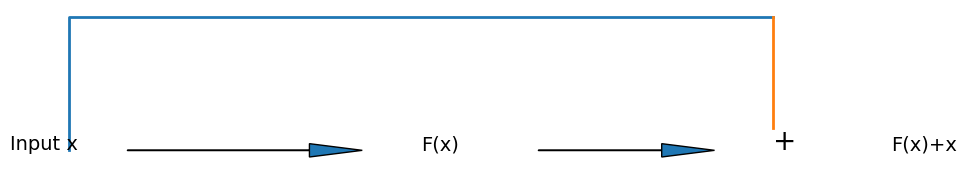

In [3]:
plt.figure(figsize=(10, 2))

plt.text(0.1, 0.5, "Input x", fontsize=14)

plt.arrow(
    0.2, 0.5,
    0.2, 0,
    head_width=0.03,
    length_includes_head=True
)

plt.text(0.45, 0.5, "F(x)", fontsize=14)

plt.arrow(
    0.55, 0.5,
    0.15, 0,
    head_width=0.03,
    length_includes_head=True
)

plt.text(0.75, 0.5, "+", fontsize=20)

plt.text(0.85, 0.5, "F(x)+x", fontsize=14)

plt.plot(
    [0.15, 0.15, 0.75],
    [0.5, 0.8, 0.8],
    linewidth=2
)

plt.plot(
    [0.75, 0.75],
    [0.8, 0.55],
    linewidth=2
)

plt.axis("off")
plt.show()

## Why Residual Connections Help

Residual connections allow information to flow directly through the network.

They make optimization easier and help prevent degradation in very deep neural networks.

This is the key idea behind ResNet.

In [4]:
model = models.resnet18(weights="DEFAULT")

## Loading ResNet18

Now we load a pretrained ResNet18 model and inspect its architecture.

We will look for residual blocks inside the network.

In [5]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Inspecting Residual Blocks

ResNet18 is built from multiple residual blocks.

Each block contains convolutional layers and a shortcut connection.

In [6]:
print(model.layer1)

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
)


In [7]:
print(model.layer1[0])

BasicBlock(
  (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


In [8]:
print(model.layer1[0].downsample)

None


## Results

We loaded a pretrained ResNet18 model and inspected its architecture.

We observed that ResNet is composed of BasicBlock modules containing convolutional layers and shortcut connections.

Residual learning allows information to bypass some layers and helps train deeper neural networks.

## Conclusion

In this notebook, we explored the main idea behind ResNet.

We demonstrated:

- the degradation problem;
- residual connections;
- a simple residual learning example;
- the architecture of ResNet18;
- the structure of residual blocks.

Residual connections make it possible to train very deep neural networks efficiently and are one of the most important ideas in modern computer vision.